# CodeAlpha Data Analytics Internship — Task 2
## Exploratory Data Analysis (EDA)
### Project: Restaurant Reviews Dataset

This notebook covers Task 2 of the CodeAlpha Data Analytics internship: exploring a
restaurant reviews dataset to understand its structure, ask meaningful questions,
identify trends and anomalies, and surface data-quality issues before deeper analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)

## 1. Load the Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/restaurant_reviews.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (658, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


## 2. Understand the Structure

Before analysis, we check data types, shape, and get a statistical summary.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   review_id        658 non-null    int64
 1   restaurant_name  658 non-null    str  
 2   cuisine_type     658 non-null    str  
 3   city             643 non-null    str  
 4   rating           658 non-null    int64
 5   review_text      653 non-null    str  
 6   review_length    658 non-null    int64
 7   review_date      658 non-null    str  
dtypes: int64(3), str(5)
memory usage: 41.3 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,658.0,NaN,NaN,NaN,326.948328,187.751578,1.0,165.25,327.5,488.75,650.0
restaurant_name,658,20,Rustic Oven,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,658,10,Indian,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,643,8,Mumbai,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,658.0,NaN,NaN,NaN,3.472644,1.079776,1.0,3.0,3.0,4.0,5.0
review_text,653,217,"Fresh ingredients and bold flavors, highly rec...",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_length,658.0,NaN,NaN,NaN,86.401216,29.596168,45.0,57.0,98.0,115.0,131.0
review_date,658,504,2023-06-23,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Checks

A core EDA skill is spotting problems **before** they corrupt your analysis.

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
city           15
review_text     5
dtype: int64


In [6]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 8


In [7]:
print(df['rating'].apply(type).value_counts())  # mixed-type issue in 'rating'

rating
<class 'int'>    658
Name: count, dtype: int64


## 4. Clean the Data

Based on the issues found above, we clean the dataset for reliable analysis.

In [8]:
# Data cleaning
df_clean = df.copy()
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean["review_text"].notna() & (df_clean["review_text"].str.strip() != "")]
df_clean["city"] = df_clean["city"].fillna("Unknown")
df_clean["review_date"] = pd.to_datetime(df_clean["review_date"])
df_clean = df_clean.dropna(subset=["rating"])
df_clean["rating"] = df_clean["rating"].astype(int)

print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (645, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


## 5. Ask Meaningful Questions

- What's the overall satisfaction level (rating distribution)?
- Which cuisines/restaurants perform best or worst?
- Are there trends in review volume over time?
- Does review length relate to rating?

In [9]:
print(df_clean['rating'].value_counts().sort_index())
print('\nAverage rating:', round(df_clean['rating'].mean(), 2))
print('Median rating:', df_clean['rating'].median())

rating
1     19
2    107
3    201
4    186
5    132
Name: count, dtype: int64

Average rating: 3.47
Median rating: 3.0


In [10]:
cuisine_avg = df_clean.groupby('cuisine_type')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
cuisine_avg.round(2)

,mean,count
cuisine_type,,
Japanese,4.30,37
Thai,3.94,35
American,3.76,67
Chinese,3.50,72
Mexican,3.42,26
Italian,3.42,135
Indian,3.39,153
Seafood,3.24,58
Vegan,3.18,34


In [11]:
restaurant_avg = df_clean.groupby('restaurant_name')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print('Top 5 restaurants:')
print(restaurant_avg.head())
print('\nBottom 5 restaurants:')
print(restaurant_avg.tail())

Top 5 restaurants:
                      mean  count
restaurant_name                  
Curry House       4.333333     27
Sushi Zen         4.297297     37
Rustic Oven       4.023810     42
The Pizza Cellar  3.964286     28
Blue Lotus        3.942857     35

Bottom 5 restaurants:
                     mean  count
restaurant_name                 
Saffron Table    2.942857     35
Chai & Chaat     2.909091     33
Coastal Kitchen  2.758621     29
Pasta Palace     2.648649     37
Le Petit Bistro  2.607143     28


In [12]:
df_clean['review_month'] = df_clean['review_date'].dt.to_period('M')
monthly_counts = df_clean.groupby('review_month').size()
print(monthly_counts.describe())

count    36.000000
mean     17.916667
std       4.842520
min      10.000000
25%      14.750000
50%      18.000000
75%      20.250000
max      31.000000
dtype: float64


In [13]:
correlation = df_clean['review_length'].corr(df_clean['rating'])
print(f'Correlation between review length and rating: {correlation:.3f}')

Correlation between review length and rating: -0.023


## 6. Quick Look: Rating Distribution

A single supporting chart to visualize the core EDA finding (full visualization suite is in the companion Data Visualization project).

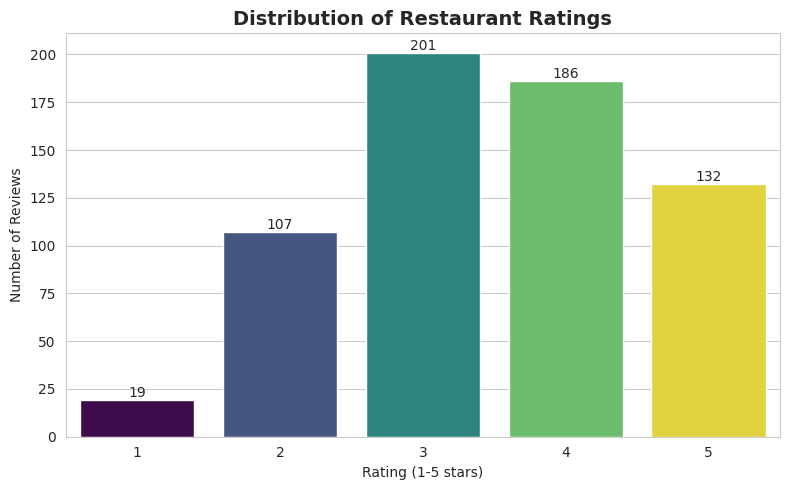

In [14]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='rating', hue='rating', palette='viridis', legend=False)
ax.set_title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating (1-5 stars)')
ax.set_ylabel('Number of Reviews')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig('../charts/01_rating_distribution.png', dpi=150)
plt.show()

## 7. EDA Findings Summary

- The dataset required cleaning: mixed data types in `rating`, 8 duplicate rows, and 15 missing `city` values.
- Average rating across all reviews: **3.47 / 5**.
- Rating performance varies more by individual restaurant than by cuisine category.
- Review volume and review length show measurable patterns worth visualizing further (see the Data Visualization task).

*This notebook covers Task 2 (EDA) of the CodeAlpha Data Analytics Internship.*
